# Türkiye elektrik piyasası: fiyatın hikayesi, 2019 → 2026

**Tarih:** 27 Ağustos 2026 · **Faz:** Katman 2/4 ön çalışması (bkz. `KATMAN_0_1_2_YOL_HARITASI.md`)

`06_presentation/tavandan_sifira.ipynb` (2021-2026) bu deftere temel. Burada seri **2019'a**
çekildi ve yalnız 2019'a çekilebilen kısımlar var: fiyat rejimleri, üretim kompozisyonu,
merit-order, ördek eğrisi, tüketim, sıfır-fiyat rejimi. Model performansı bölümleri (`tavandan_sifira`
§10-13) burada YOK — `gold.ptf_predictions_daily` 2024-08'de başlıyor, o kısım benchmark işinin parçası.

**Veri:** `build_market_history.py` → `market_history_2019_2026.pkl`. 2021+ proje DB'si,
2019-2020 EPİAŞ Şeffaflık (`eptr2`), kur/Brent frankfurter+yfinance. Saatlik, tz-naive (+03, DST yok).

### Kısıtlar
- **Gaz referans fiyatı** EPİAŞ'ta ~2021 Nisan'da başladı → 2019-2020 için gaz-fiyatı/merit-order
  analizi Brent ile vekil.
- **Fiyat tavanı** ₺ cinsinden zamanla değişti; bağlayıcı ₺1745 tavanı 2022 Nisan'da geldi.
- **`solar`** yalnız **lisanslı** santral üretimi. Lisanssız (çatı) GES metrelenmez — talebi düşürerek
  görünür (§7, §9).


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_pickle(Path.cwd() / 'market_history_2019_2026.pkl')
df[df.columns] = df[df.columns].interpolate(limit=6).ffill().bfill()  # ~41 dağınık DB boşluğu
df['year'] = df.index.year; df['month'] = df.index.to_period('M'); df['hour'] = df.index.hour
plt.rcParams.update({'figure.figsize': (12, 4), 'axes.grid': True, 'grid.alpha': .25, 'font.size': 10})

print(f'{len(df):,} saat  {df.index.min().date()} -> {df.index.max().date()}  {df.shape[1]} kolon')
print(df[['price_usd','price_try','cons_mw','gen_total','wind','solar','gas','renewable_share']].describe().round(1).T)


67,128 saat  2019-01-01 -> 2026-08-28  34 kolon
                   count     mean     std      min      25%      50%      75%  \
price_usd        67128.0     71.5    46.0      0.0     43.5     61.8     83.4   
price_try        67128.0   1544.7  1234.6      0.0    316.5   1488.5   2586.2   
cons_mw          67128.0  37087.2  6504.8  15333.3  32131.3  36959.8  41386.7   
gen_total        67128.0  35361.7  5867.9  11175.3  31211.7  35230.0  39384.0   
wind             67128.0   3729.4  2235.4     42.5   1889.2   3381.7   5217.3   
solar            67128.0    409.6   745.5     -3.0      0.0     14.2    496.5   
gas              67128.0   8008.7  4185.7    276.3   4555.9   7954.9  11098.9   
renewable_share  67128.0      0.4     0.1      0.1      0.3      0.4      0.5   

                     max  
price_usd          264.2  
price_try         4800.0  
cons_mw          59503.7  
gen_total        56219.1  
wind             12060.0  
solar             4220.3  
gas              19453.6  
renewa

## 1. Fiyatın seyri — yedi yıl, sekiz rejim

USD/MWh ve TRY/MWh birlikte: TRY'de fiyat neredeyse monoton artıyor (kur + enflasyon), USD'de
gerçek arz-talep hikayesi görünüyor. **USD ana analiz birimi.**


In [2]:
g = df.groupby('year')['price_usd'].agg(ort='mean', medyan='median',
        p10=lambda s: s.quantile(.1), p90=lambda s: s.quantile(.9),
        sifir_saat_pct=lambda s: (s <= 1).mean()*100).round(1)
g['price_try_ort'] = df.groupby('year')['price_try'].mean().round(0)
g


,ort,medyan,p10,p90,sifir_saat_pct,price_try_ort
year,,,,,,
2019,46.0,52.7,24.8,57.4,2.9,260.0
2020,40.1,41.4,28.6,54.2,1.7,279.0
2021,55.6,47.0,37.8,79.9,0.0,508.0
2022,147.5,137.7,80.8,236.0,0.4,2511.0
2023,96.6,87.1,52.9,161.1,0.3,2189.0
2024,68.1,73.0,40.8,87.5,0.6,2236.0
2025,66.4,72.8,38.4,83.8,1.0,2620.0
2026,41.3,39.8,3.7,78.7,7.4,1867.0


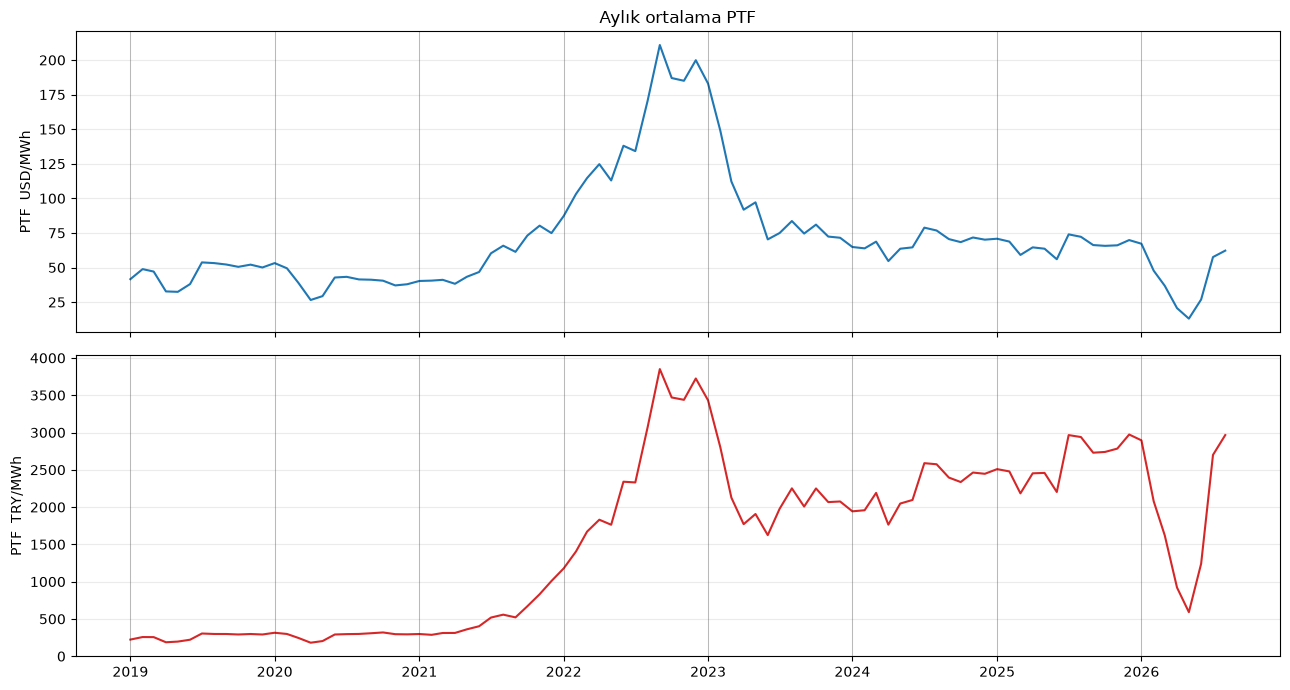

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
mo = df.groupby('month').agg(usd=('price_usd','mean'), tryv=('price_try','mean'))
mo.index = mo.index.to_timestamp()
ax[0].plot(mo.index, mo.usd, lw=1.5, color='tab:blue'); ax[0].set(ylabel='PTF  USD/MWh', title='Aylık ortalama PTF')
ax[1].plot(mo.index, mo.tryv, lw=1.5, color='tab:red'); ax[1].set(ylabel='PTF  TRY/MWh')
for a in ax:
    for yr in range(2019, 2027): a.axvline(pd.Timestamp(f'{yr}-01-01'), color='k', lw=.5, alpha=.3)
plt.tight_layout(); plt.show()


### Rejimler (USD ortalamasıyla)

| # | Dönem | ~PTF USD | Ne oldu |
|---|---|---|---|
| 1 | 2019 | ~$46 | Kur şoku sonrası durgun talep, düşük emtia |
| 2 | 2020 H1 | ~$30-40 | **COVID** — talep çöküşü, dip |
| 3 | 2020 H2 – 2021 | ~$50-60 | Toparlanma, gaz fiyatı tırmanışı başlıyor |
| 4 | 2022 | ~$147 | **Küresel enerji krizi** — gaz patlaması, ₺ tavanı devrede |
| 5 | 2023 | ~$97 | Kriz gevşiyor ama yüksek plato |
| 6 | 2024 | ~$68 | Normalleşme, $70 platosu |
| 7 | 2025 | ~$66 | İstikrar, yenilenebilir payı artıyor |
| 8 | 2026 | ~$41 | **Yenilenebilir/hidro bolluğu** — sıfır-fiyat saatleri patlıyor |

_(sayıları üstteki tabloyla doğrula)_


## 2. Fiyatın sınıra dayandığı saatler

TRY tavanı zamanla değişti; ampirik yaklaşım: her ay o ayın **maksimum PTF'sine** >%99 yakın kaç saat.

> ⚠️ 2019-2020 satırları gürültü — o yıllarda bağlayıcı bir tavan yoktu, metrik sadece 'aylık zirveye
> yakın' saatleri sayıyor. Anlamlı kısım 2021'den itibaren: tavana yapışma %2 → %25 (2022) → %21 (2025).
> 2026'da hem tavan hem **taban** %7 — çift kutuplu rejim.


In [4]:
mx = df.groupby('month')['price_try'].transform('max')
df['tavanda'] = df['price_try'] >= 0.99 * mx
df['tabanda'] = df['price_usd'] <= 1.0
t = df.groupby('year').agg(tavan_saat=('tavanda','sum'), taban_saat=('tabanda','sum'),
        ay_max_try=('price_try','max'))
t['tavan_pct'] = (t.tavan_saat / df.groupby('year').size() * 100).round(1)
t['taban_pct'] = (t.taban_saat / df.groupby('year').size() * 100).round(1)
t.round(0)


,tavan_saat,taban_saat,ay_max_try,tavan_pct,taban_pct
year,,,,,
2019,128,257,500.0,2.0,3.0
2020,57,147,982.0,1.0,2.0
2021,1338,0,1217.0,15.0,0.0
2022,2152,35,4800.0,25.0,0.0
2023,1118,25,4200.0,13.0,0.0
2024,1410,57,3000.0,16.0,1.0
2025,1814,87,3400.0,21.0,1.0
2026,425,427,4500.0,7.0,7.0


## 3. Üretim kompozisyonu — 2019 → 2026

Yıllık ortalama üretim (MW) yakıt tipine göre, ve pay (%).


In [5]:
fuels = ['gas','import_coal','lignite','black_coal','asphaltite','dammed_hydro','river_hydro',
         'wind','solar','geothermal','fuel_oil','biomass']
comp = df.groupby('year')[fuels].mean().round(0)
comp


,gas,import_coal,lignite,black_coal,asphaltite,dammed_hydro,river_hydro,wind,solar,geothermal,fuel_oil,biomass
year,,,,,,,,,,,,
2019,6265.0,6895.0,5333.0,390.0,265.0,7491.0,2624.0,2456.0,21.0,939.0,106.0,359.0
2020,7750.0,7111.0,4302.0,431.0,253.0,6526.0,2335.0,2788.0,48.0,1061.0,36.0,463.0
2021,12253.0,6266.0,4906.0,443.0,271.0,4630.0,1702.0,3527.0,177.0,1154.0,38.0,673.0
2022,8204.0,7214.0,5110.0,467.0,179.0,5324.0,2279.0,3945.0,317.0,1167.0,79.0,855.0
2023,7577.0,8204.0,4631.0,474.0,181.0,5042.0,2225.0,3849.0,441.0,1154.0,80.0,927.0
2024,7218.0,8512.0,4745.0,520.0,131.0,6486.0,2003.0,4151.0,596.0,1165.0,83.0,980.0
2025,8946.0,8689.0,4436.0,518.0,216.0,4723.0,1808.0,4480.0,883.0,1215.0,86.0,959.0
2026,4740.0,6338.0,4448.0,472.0,198.0,9796.0,3045.0,5115.0,996.0,1199.0,83.0,904.0


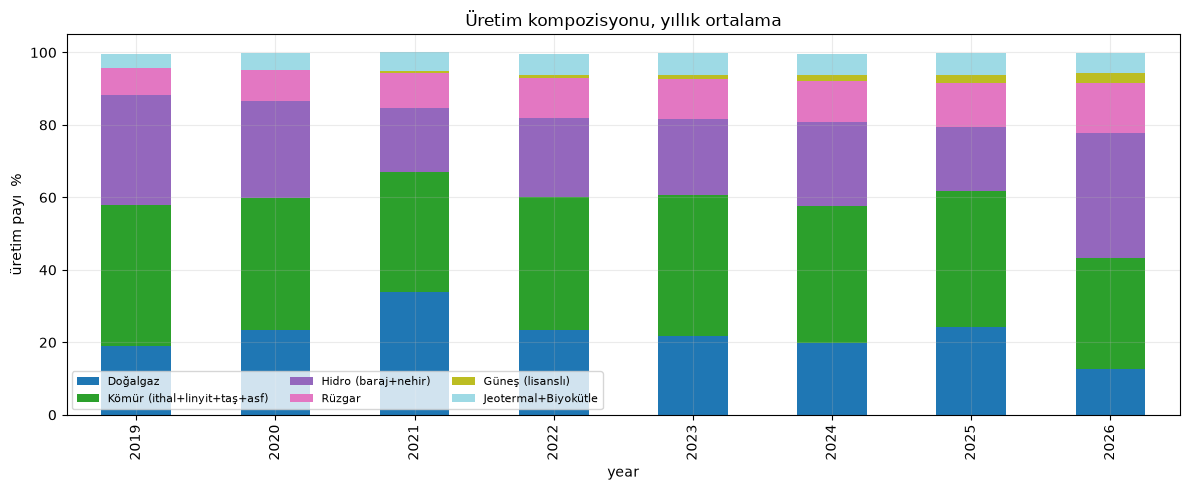

,Doğalgaz,Kömür (ithal+linyit+taş+asf),Hidro (baraj+nehir),Rüzgar,Güneş (lisanslı),Jeotermal+Biyokütle
year,,,,,,
2019,18.9,38.9,30.5,7.4,0.1,3.9
2020,23.4,36.5,26.8,8.4,0.1,4.6
2021,34.0,33.0,17.6,9.8,0.5,5.1
2022,23.3,36.9,21.6,11.2,0.9,5.8
2023,21.8,38.8,20.9,11.1,1.3,6.0
2024,19.7,38.0,23.2,11.3,1.6,5.9
2025,24.2,37.5,17.7,12.1,2.4,5.9
2026,12.7,30.7,34.4,13.7,2.7,5.6


In [6]:
share = comp.div(comp.sum(axis=1), axis=0) * 100
grp = pd.DataFrame({
    'Doğalgaz': share['gas'],
    'Kömür (ithal+linyit+taş+asf)': share[['import_coal','lignite','black_coal','asphaltite']].sum(axis=1),
    'Hidro (baraj+nehir)': share[['dammed_hydro','river_hydro']].sum(axis=1),
    'Rüzgar': share['wind'], 'Güneş (lisanslı)': share['solar'],
    'Jeotermal+Biyokütle': share[['geothermal','biomass']].sum(axis=1),
}).round(1)
ax = grp.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab20')
ax.set(ylabel='üretim payı  %', title='Üretim kompozisyonu, yıllık ortalama'); ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()
grp


## 4. Yenilenebilir devrimi

Rüzgar + lisanslı güneş üretimi ve toplam yenilenebilir pay. 2026'daki fiyat çöküşünün fiziksel sürücüsü.


In [7]:
r = df.groupby('year').agg(
    wind_ort=('wind','mean'), solar_ort=('solar','mean'),
    wind_max=('wind','max'), solar_max=('solar','max'),
    yenilenebilir_pay=('renewable_share', lambda s: s.mean()*100),
    hidro_pay=('hydro_share', lambda s: s.mean()*100)).round(1)
r


,wind_ort,solar_ort,wind_max,solar_max,yenilenebilir_pay,hidro_pay
year,,,,,,
2019,2455.7,21.5,6290.3,144.8,42.0,30.5
2020,2787.6,47.9,6861.0,298.0,40.5,27.1
2021,3527.5,176.9,8477.9,764.4,32.9,17.3
2022,3945.3,316.7,9327.7,1289.8,39.4,21.4
2023,3849.2,440.7,9737.6,1547.4,39.0,20.7
2024,4150.7,595.6,10078.8,2226.3,42.5,23.2
2025,4480.1,882.7,10612.4,3394.4,38.6,17.5
2026,5115.3,996.5,12060.0,4220.3,57.7,35.1


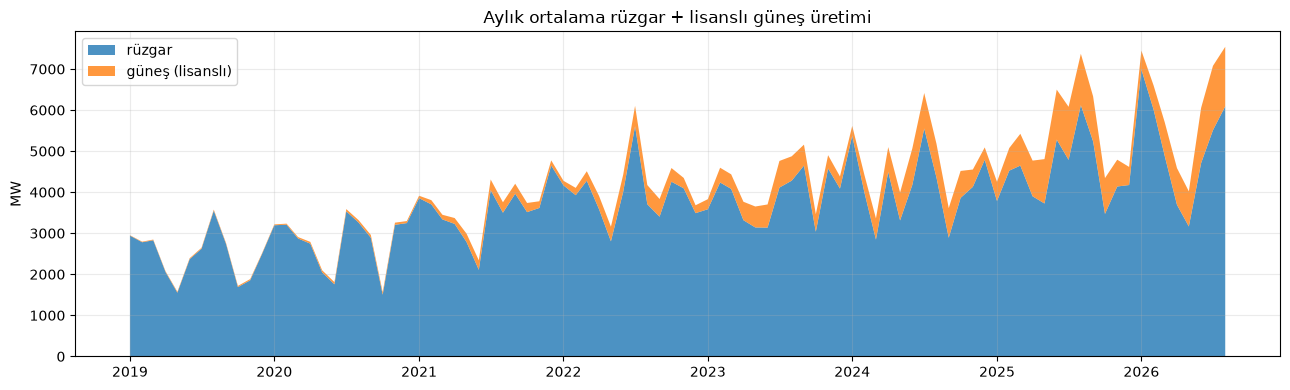

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
w = df.groupby('month')[['wind','solar']].mean(); w.index = w.index.to_timestamp()
ax.stackplot(w.index, w['wind'], w['solar'], labels=['rüzgar','güneş (lisanslı)'], alpha=.8)
ax.set(ylabel='MW', title='Aylık ortalama rüzgar + lisanslı güneş üretimi'); ax.legend()
plt.tight_layout(); plt.show()


## 5. Merit-order — fiyatı ne belirliyor?

Hipotez: doğalgaz saatlerin çoğunda marjinal santral → PTF'yi gaz maliyeti belirliyor. Test:
PTF (USD) ile (a) gaz üretim payı, (b) Brent, (c) net yük [tüketim − rüzgar − güneş] korelasyonu,
**dönem dönem** (rejim değişince ilişki de değişiyor mu?).


In [9]:
def corr_block(g):
    return pd.Series({
        'corr_gaz_payı': g['price_usd'].corr(g['gas_share']),
        'corr_brent': g['price_usd'].corr(g['brent']),
        'corr_net_yük': g['price_usd'].corr(g['net_load']),
        'corr_yenilenebilir_pay': g['price_usd'].corr(g['renewable_share']),
        'ort_PTF_usd': g['price_usd'].mean()})
df.groupby('year').apply(corr_block, include_groups=False).round(2)


,corr_gaz_payı,corr_brent,corr_net_yük,corr_yenilenebilir_pay,ort_PTF_usd
year,,,,,
2019,0.61,-0.31,0.62,-0.52,46.03
2020,0.35,0.49,0.68,-0.33,40.11
2021,0.42,0.65,0.44,-0.34,55.60
2022,0.47,-0.25,0.38,-0.53,147.50
2023,0.54,0.06,0.26,-0.46,96.56
2024,0.63,-0.16,0.62,-0.44,68.10
2025,0.65,0.02,0.47,-0.41,66.42
2026,0.53,-0.44,0.52,-0.64,41.32


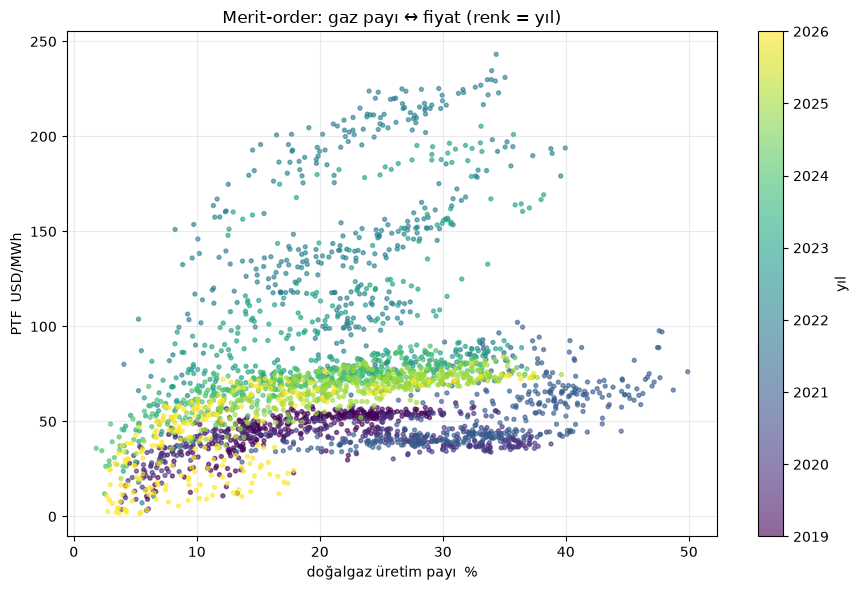

In [10]:
# günlük çözünürlükte: PTF vs gaz payı, rejim renkli
d = df.resample('D').mean(numeric_only=True).dropna(subset=['price_usd','gas_share'])
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(d['gas_share']*100, d['price_usd'], c=d.index.year, cmap='viridis', s=8, alpha=.6)
ax.set(xlabel='doğalgaz üretim payı  %', ylabel='PTF  USD/MWh', title='Merit-order: gaz payı ↔ fiyat (renk = yıl)')
plt.colorbar(sc, label='yıl'); plt.tight_layout(); plt.show()


## 6. Gün içi şekil — ördek eğrisinin doğuşu

Saat-bazında ortalama PTF (USD), yıl yıl. Güneş büyüdükçe öğlen saatleri çukurlaşıyor,
akşam rampası dikleşiyor.


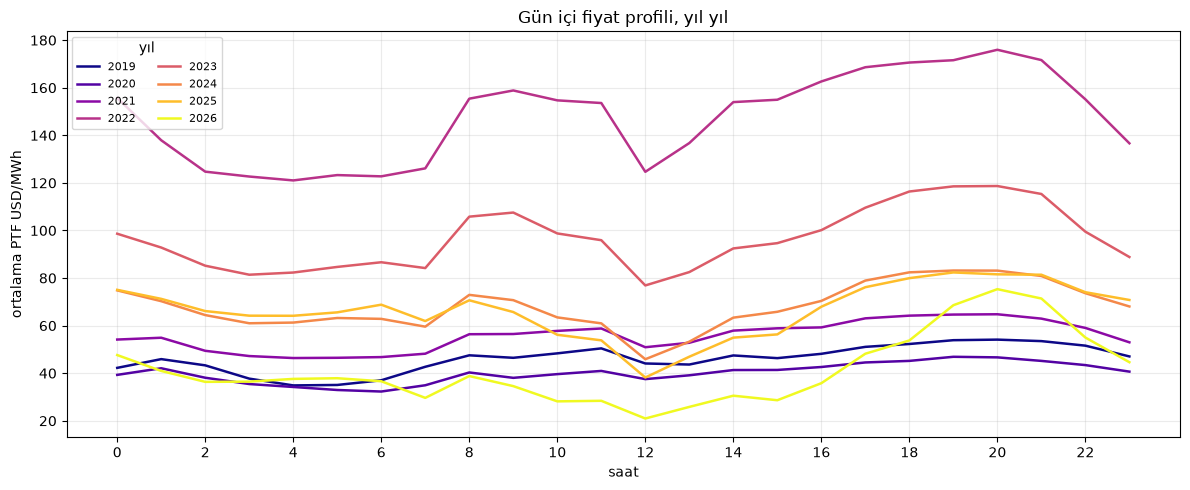

year,2019,2020,2021,2022,2023,2024,2025,2026
hour,,,,,,,,
0,42.2,39.3,54.2,155.7,98.6,74.8,75.0,47.6
1,45.9,42.1,54.9,137.9,92.8,70.3,71.3,41.0
2,43.3,38.1,49.4,124.7,85.2,64.4,66.1,36.4
3,37.7,35.4,47.2,122.7,81.4,61.0,64.2,36.5
4,34.9,34.2,46.4,121.0,82.3,61.3,64.1,37.6
5,35.1,32.9,46.5,123.3,84.7,63.2,65.6,37.9
6,37.0,32.3,46.8,122.8,86.6,62.8,68.8,36.6
7,42.7,34.9,48.2,126.1,84.2,59.6,61.9,29.6
8,47.5,40.3,56.4,155.4,105.8,72.9,70.7,38.8


In [11]:
hp = df.pivot_table(index='hour', columns='year', values='price_usd', aggfunc='mean')
ax = hp.plot(figsize=(12, 5), colormap='plasma', lw=1.8)
ax.set(xlabel='saat', ylabel='ortalama PTF USD/MWh', xticks=range(0,24,2), title='Gün içi fiyat profili, yıl yıl')
ax.legend(title='yıl', ncol=2, fontsize=8); plt.tight_layout(); plt.show()
hp.round(1)


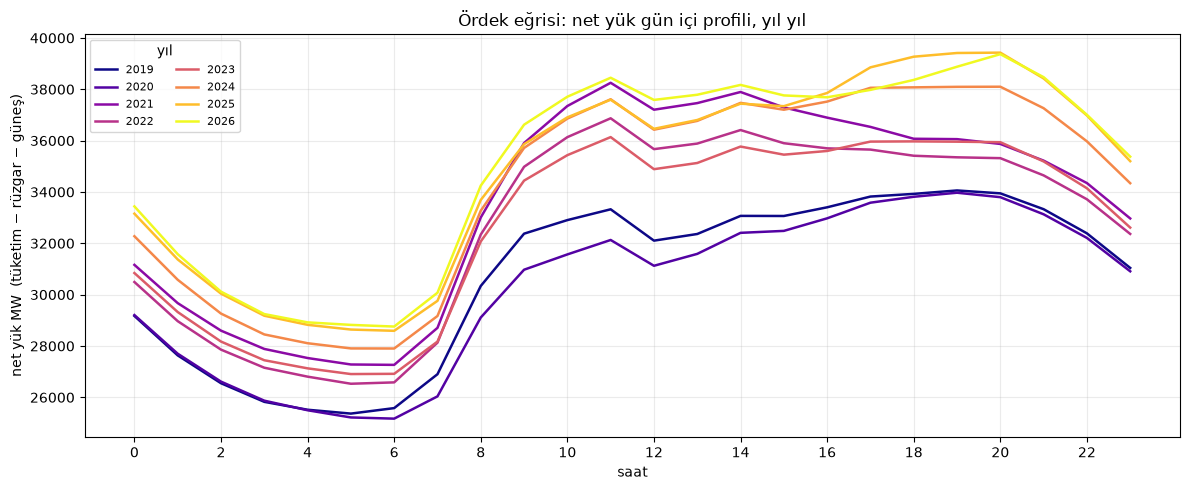

In [12]:
# net yük gün içi profili (ördek): tüketim - rüzgar - güneş
nl = df.pivot_table(index='hour', columns='year', values='net_load', aggfunc='mean')
ax = nl.plot(figsize=(12, 5), colormap='plasma', lw=1.8)
ax.set(xlabel='saat', ylabel='net yük MW  (tüketim − rüzgar − güneş)', xticks=range(0,24,2),
       title='Ördek eğrisi: net yük gün içi profili, yıl yıl')
ax.legend(title='yıl', ncol=2, fontsize=8); plt.tight_layout(); plt.show()


## 7. Tüketim trendi

Yıllık ortalama + mevsimsel örüntü. Lisanssız güneşin talep-bastırma etkisi öğlen saatlerinde.


In [13]:
c = df.groupby('year')['cons_mw'].agg(ort='mean', yaz_max='max', kis_min='min').round(0)
c['yoy_pct'] = (c['ort'].pct_change()*100).round(1)
c


,ort,yaz_max,kis_min,yoy_pct
year,,,,
2019,33227.0,49086.0,18204.0,NaN
2020,33130.0,49342.0,15333.0,-0.3
2021,37305.0,55575.0,20553.0,12.6
2022,36965.0,51354.0,19209.0,-0.9
2023,37023.0,54045.0,19595.0,0.2
2024,39013.0,57772.0,20062.0,5.4
2025,40241.0,59504.0,21419.0,3.1
2026,41212.0,58835.0,21828.0,2.4


In [14]:
# öğlen (12-15) tüketim payı düşüyor mu — lisanssız güneş vekili
df['gunduz'] = df['hour'].between(11, 15)
noon = df[df.gunduz].groupby('year')['cons_mw'].mean()
allh = df.groupby('year')['cons_mw'].mean()
pd.DataFrame({'öğlen_tüketim': noon.round(0), 'gün_ort': allh.round(0),
             'öğlen/ort': (noon/allh).round(3)})


,öğlen_tüketim,gün_ort,öğlen/ort
year,,,
2019,35202.0,33227.0,1.059
2020,34760.0,33130.0,1.049
2021,41456.0,37305.0,1.111
2022,40759.0,36965.0,1.103
2023,40417.0,37023.0,1.092
2024,42639.0,39013.0,1.093
2025,43656.0,40241.0,1.085
2026,45021.0,41212.0,1.092


## 8. Sıfır-fiyat rejimi (2025-2026)

Ne zaman, hangi saatlerde, hangi koşulda PTF ≈ 0? Yenilenebilir baskısı [(rüzgar+güneş+hidro)/tüketim]
ve net yük ile ilişki.


sıfır-fiyat saat sayısı toplam: 1,035  (1.5%)
yıla göre: {2019: 257, 2020: 147, 2022: 35, 2023: 25, 2024: 57, 2025: 87, 2026: 427}


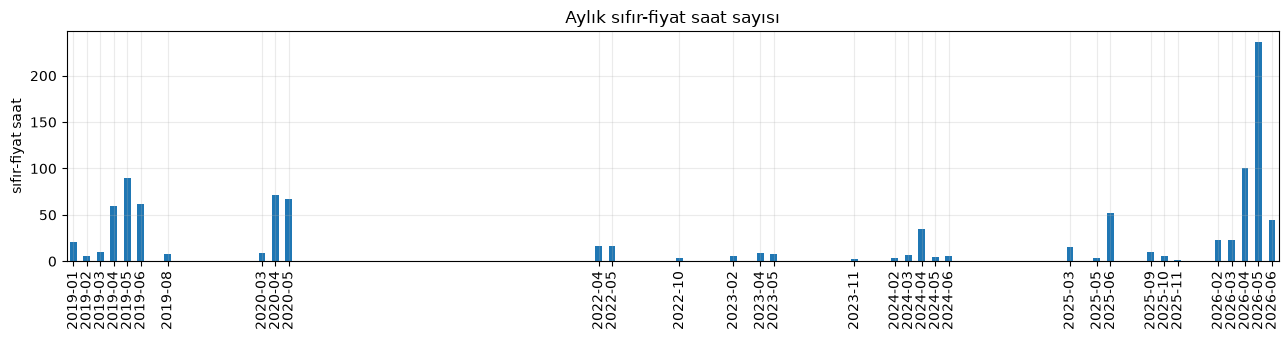

In [15]:
df['yenilenebilir_baski'] = df['gen_renewable'] / df['cons_mw']
z = df[df['price_usd'] <= 1]
print(f'sıfır-fiyat saat sayısı toplam: {len(z):,}  ({len(z)/len(df)*100:.1f}%)')
by_year = z.groupby('year').size()
print('yıla göre:', by_year.to_dict())
zm = z.groupby(z.index.to_period('M')).size()
ax = zm[zm > 0].plot(kind='bar', figsize=(13,3.5)); ax.set(ylabel='sıfır-fiyat saat', title='Aylık sıfır-fiyat saat sayısı')
plt.tight_layout(); plt.show()


In [16]:
# 2026 sıfır saatler: saat dağılımı + koşul ortalamaları
z26 = df[(df.year == 2026) & (df.price_usd <= 1)]
nz26 = df[(df.year == 2026) & (df.price_usd > 1)]
print('2026 sıfır saat, saat histogramı:', z26.groupby('hour').size().to_dict())
pd.DataFrame({
  'sıfır saatler': z26[['yenilenebilir_baski','net_load','solar','wind','gen_hydro','cons_mw']].mean(),
  'sıfır-olmayan': nz26[['yenilenebilir_baski','net_load','solar','wind','gen_hydro','cons_mw']].mean(),
}).round(2)


2026 sıfır saat, saat histogramı: {0: 1, 1: 2, 2: 3, 3: 2, 4: 3, 5: 3, 6: 7, 7: 18, 8: 26, 9: 38, 10: 44, 11: 45, 12: 58, 13: 52, 14: 44, 15: 41, 16: 25, 17: 10, 18: 4, 23: 1}


,sıfır saatler,sıfır-olmayan
yenilenebilir_baski,0.48,0.52
net_load,30678.45,35454.05
solar,1787.38,933.15
wind,2708.86,5308.00
gen_hydro,10028.07,12993.60
cons_mw,35174.69,41695.21


## 9. Sentez — 2019'dan 2026'ya tek hikaye

**2019-2020 — düşük ve durgun.** PTF ~$40-46. 2018 kur krizi sonrası talep zayıf, emtia ucuz.
Bahar 2019 ve COVID baharı 2020'de **sıfır-fiyat saatleri** (404 saat) — hidro eriyişi + çökük talep
(o saatlerde hidro 11,4 GW, yenilenebilir pay %65, tüketim 24 GW). **2026 çöküşünün provası** —
aynı mekanizma, küçük ölçek.

**2021-2023 — kriz ve tavan.** Gaz payı 2021'de %19→%34'e fırladı (hidro %30→%17 kuraklık), PTF $56.
2022 küresel enerji krizi: PTF **$147**, yılın **%25'i tavana yapışık**, ₺ tavanı 4800'e çekildi.
2023 gevşeme ama $97 platosu.

**2024-2025 — normalleşme, $70 platosu.** Gaz payı ~%20-24, PTF $66-68. Tavana yapışma hâlâ yüksek
(%16-21) — ₺ tavanı enflasyona göre ayarlandıkça akşam zirvelerinde bağlanıyor. Güneş payı %1,6→%2,4.

**2026 — yenilenebilir/hidro çöküşü.** PTF **$41**, p10 **$3,7**, yılın **%7,4'ü sıfır**. Sürücü:
yenilenebilir pay %38→**%58**, hidro payı %17→**%35** (islak yıl, baraj hidro 4,7→9,8 GW), gaz payı
%24→**%13**. Gaz artık çoğu öğlen saatinde marjinal değil.

**Merit-order kayması.** Gaz payı ↔ PTF korelasyonu her yıl pozitif (0,4-0,65) — gaz hâlâ fiyat
belirleyici. Yenilenebilir pay ↔ PTF korelasyonu her yıl negatif, 2026'da **-0,64**'e derinleşiyor:
yenilenebilir ne kadar çoksa fiyat o kadar düşük.

**Ördek eğrisi.** Gün-içi profil 2019'da düz (öğlen ~akşam). 2024'ten itibaren öğlen (12-15) çukuru
açılıyor: 2026'da saat 12 ortalaması **$21**, akşam 20 **$75** — 3,5×. Sıfır-fiyat saatleri 9-15 arası
yoğun (güneş zirvesi). Net yük öğlen çöküyor, akşam rampası dikleşiyor.

**Tek cümle:** 2019-2026 Türkiye GÖP'ü, gaz-belirlenen bir fiyat rejiminden (kriz zirvesi 2022)
yenilenebilir-belirlenen bir rejime (çöküş 2026) geçti; sıfır-fiyat 2019'da hidro kaynaklı bir
bahar anomalisiydi, 2026'da solar+hidro kaynaklı yapısal bir gün-içi olguya dönüştü.
